# **Predictive Model Evaluation**

## Objectives

* Extend notebook [09_predictive_modelling](/jupyter_notebooks/09_predictive_modelling.ipynb) to evaluate the fitted classification pipeline's performance
* Assess feature importance to understand model behaviour
* Revisit modelling choices and refit if performance does not meet requirements
* Answer Business Requirement 2: *TCS Hotels wants a machine learning model capable of predicting the likelihood of a booking cancellation, accessed through an operational dashboard that supports the reservations team in three ways: a risk report of upcoming arrivals, individual reservation search and a prospective booking risk assessor*

## Inputs

* Classification Pipeline "outputs/ml_pipeline/cancel_predict/v1/classification_model_pipeline.pkl"
* Train and test datasets from "outputs/ml_pipeline/preprocessing"

## Outputs

* Confusion matrix and classification report for train and test sets
* Feature importance plot
* Updated preprocessing pipeline saved to "outputs/ml_pipeline/cancel_predict/v2/classification_preprocessing_pipeline.pkl"
* Updated modelling pipeline saved to "outputs/ml_pipeline/cancel_predict/v2/classification_model_pipeline.pkl"
* Trained classification model for Business Requirement 2, to be integrated into the operational dashboard

## Additional Comments

* Feature importance analysis identified a potential data leakage risk in `deposit_type`. This was investigated and validated through an ablation study, resulting in its removal from the final (v2) pipeline. See the Feature Importance section for full reasoning.


---

# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\dev\\cancel-protect\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir

'c:\\dev\\cancel-protect'

---

## Load Data

In [3]:
import pandas as pd
import joblib

X_train = pd.read_csv("outputs/ml_pipeline/preprocessing/X_train.csv")
X_test = pd.read_csv("outputs/ml_pipeline/preprocessing/X_test.csv")
y_train = pd.read_csv("outputs/ml_pipeline/preprocessing/y_train.csv").squeeze()
y_test = pd.read_csv("outputs/ml_pipeline/preprocessing/y_test.csv").squeeze()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


(95344, 27) (95344,) (23836, 27) (23836,)


* Load the fitted pipeline

In [4]:
classification_model_pipeline = joblib.load(
    "outputs/ml_pipeline/cancel_predict/v1/classification_model_pipeline.pkl"
)
classification_model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('DropFeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute 

---

## Generate Predictions

In [5]:
y_train_pred = classification_model_pipeline.predict(X_train)
y_test_pred = classification_model_pipeline.predict(X_test)

---

## Confusion Matrix

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="winter",
                xticklabels=["Not Cancelled", "Cancelled"],
                yticklabels=["Not Cancelled", "Cancelled"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()


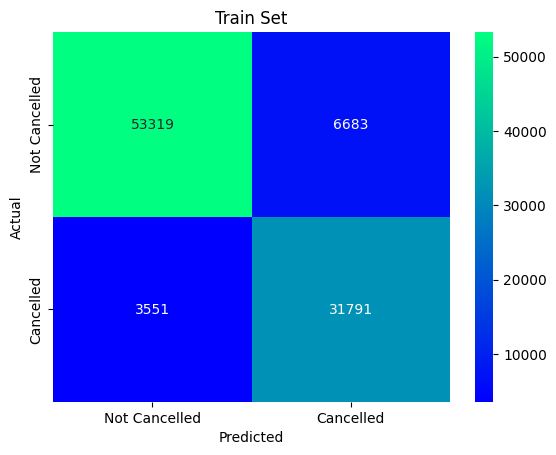

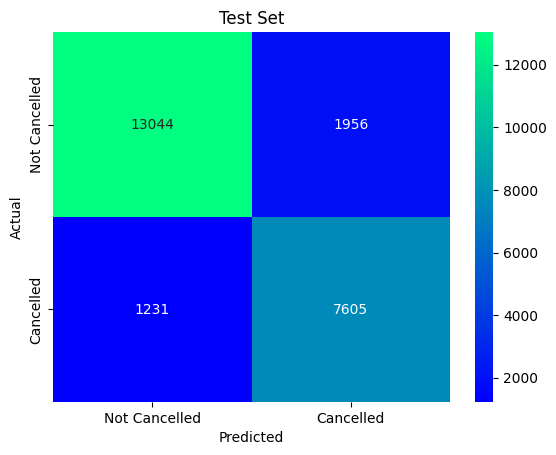

In [7]:
plot_confusion_matrix(y_train, y_train_pred, "Train Set")
plot_confusion_matrix(y_test, y_test_pred, "Test Set")

---

## Classification Report

In [8]:
from sklearn.metrics import classification_report

print("TRAIN SET\n")
print(classification_report(y_train, y_train_pred, target_names=["Not Cancelled", "Cancelled"]))

print("TEST SET\n")
print(classification_report(y_test, y_test_pred, target_names=["Not Cancelled", "Cancelled"]))

TRAIN SET

               precision    recall  f1-score   support

Not Cancelled       0.94      0.89      0.91     60002
    Cancelled       0.83      0.90      0.86     35342

     accuracy                           0.89     95344
    macro avg       0.88      0.89      0.89     95344
 weighted avg       0.90      0.89      0.89     95344

TEST SET

               precision    recall  f1-score   support

Not Cancelled       0.91      0.87      0.89     15000
    Cancelled       0.80      0.86      0.83      8836

     accuracy                           0.87     23836
    macro avg       0.85      0.87      0.86     23836
 weighted avg       0.87      0.87      0.87     23836



In [9]:
from sklearn.metrics import recall_score

train_recall = recall_score(y_train, y_train_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)

target_recall = 0.80

print(f"Train recall: {train_recall:.2f}")
print(f"Test recall: {test_recall:.2f}")
print(f"Target recall met on test set: {test_recall >= target_recall}")

Train recall: 0.90
Test recall: 0.86
Target recall met on test set: True


* The final XGBoost model was configured with `scale_pos_weight` to address class imbalance, alongside tuned `learning_rate=0.2` and `n_estimators=200`
* Train and test performance show only a modest gap (accuracy 0.89 vs 0.87, Cancelled recall 0.90 vs 0.86), indicating the model generalises well to unseen data without significant overfitting
* On the test set, the model correctly identified 7,605 of 8,836 actual cancellations (recall 0.86), comfortably exceeding the 0.8 recall target set out in the business understanding
* Of the remaining cancellations, 1,231 were missed (false negatives) and 1,956 bookings were incorrectly flagged as likely to cancel (false positives); this trade-off reflects the deliberate prioritisation of recall over precision via class weighting, consistent with the business requirement to catch as many at-risk bookings as possible
* Precision for the Cancelled class (0.80) remains reasonably strong despite this trade-off, meaning 4 in 5 bookings flagged as at-risk are genuine cancellations
* Overall accuracy (0.87) and macro/weighted F1-scores (0.86-0.87) indicate the model performs consistently across both classes rather than favouring the majority class, despite the underlying class imbalance
* These results confirm the final model meets its primary business objective of recall ≥ 0.8, with an acceptable precision trade-off

---

## Feature Importance

In [10]:
preprocessed_sample = classification_model_pipeline.named_steps["Preprocessing"].transform(X_train)
feature_names = preprocessed_sample.columns

model = classification_model_pipeline.named_steps["model"]
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)


,Feature,Importance
38,deposit_type_Non Refund,0.685269
14,required_car_parking_spaces,0.076747
24,market_segment_Online TA,0.061488
9,previous_cancellations,0.020497
7,country,0.014854
15,total_of_special_requests,0.013485
25,market_segment_Direct,0.011515
41,customer_type_Transient,0.011313
11,agent,0.006755
10,previous_bookings_not_canceled,0.006236


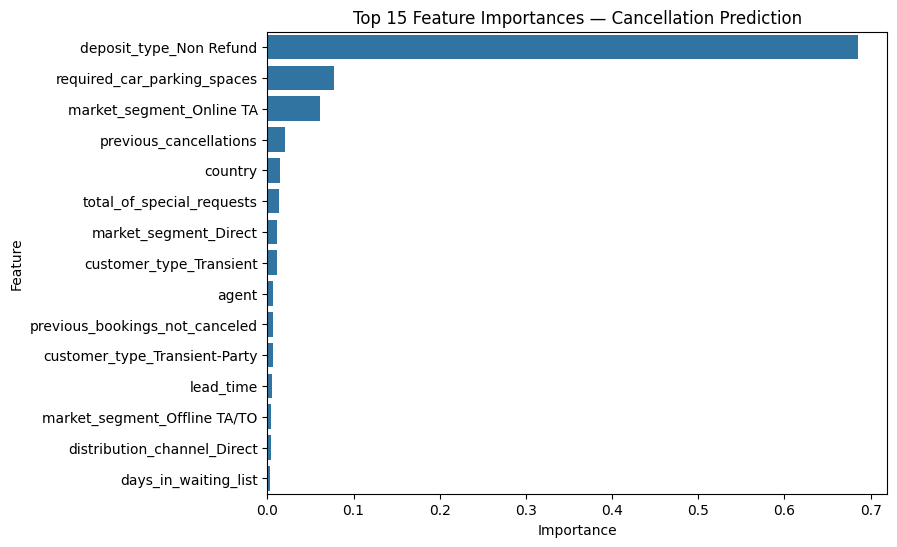

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances — Cancellation Prediction")
plt.show()

* Feature importance analysis identified `deposit_type_Non_Refund` as by far the strongest predictor in the model (importance 0.685), nearly 9x greater than the next-ranked feature (`required_car_parking_spaces`, 0.077)
* This scale of dominance, combined with the feature's near-perfect association with cancellation outcomes (Non Refund type has a 99% cancellation rate as discovered in the [correlation study](/jupyter_notebooks/05_correlation_study.ipynb)), raises a concern that it may be acting less as a genuine predictive signal and more as a proxy for the target itself
* There is ambiguity in how the variable is derived leading to concerns that there could be data leakage:

> Value calculated based on the payments identified for the booking in the transaction (TR) table before the booking's arrival or cancellation date. <br>
> Non Refund – a deposit was made in the value of the total stay cost; [*Hotel booking demand datasets*](https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/)

* This definition confirms the deposit_type value is fixed by the point of arrival or cancellation, it does not indicate if the deposit was present at the point of booking
* Given this unresolved ambiguity and the disproportionate influence of the feature on the model, an ablation study is appropriate, retraining the model with `deposit_type_Non_Refund` removed to assess whether its predictive contribution reflects information genuinely available at enquiry time, or whether performance is being propped up by a feature of uncertain provenance

* Test model performace without `deposit_type`

In [17]:
from feature_engine.selection import DropFeatures
from feature_engine.imputation import ArbitraryNumberImputer, CategoricalImputer
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OneHotEncoder, RareLabelEncoder, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from utils.custom_transformers import undefined_meal

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def classification_pipeline_no_deposit():
    pipeline_base = Pipeline([
        ("DropFeatures", DropFeatures(features_to_drop=["company", "arrival_date_year", "deposit_type", "arrival_date_week_number"])),
        ("FunctionTransformer", FunctionTransformer(undefined_meal)),
        ("ArbitraryNumberImputer", ArbitraryNumberImputer(arbitrary_number=0, variables="agent")),
        ("CategoricalImputer", CategoricalImputer(imputation_method="frequent", variables="country")),
        ("Winsorizer", Winsorizer(capping_method="iqr", tail="right", fold=1.5, variables=["lead_time", "adr",
                                                                                           "stays_in_weekend_nights", "stays_in_week_nights"])),
        ("RareLabelEncoder", RareLabelEncoder(tol=0.01, variables="country")),
        ("OrdinalEncoder", OrdinalEncoder(encoding_method="arbitrary", variables="country", ignore_format=True)),
        ("MonthEncoder", OneHotEncoder(variables="arrival_date_month")) ,
        ("OneHotEncoder", OneHotEncoder(variables=["hotel", "meal", "market_segment", "distribution_channel",
                                                   "reserved_room_type", "customer_type"], drop_last=True)),
        ("model", XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            learning_rate=0.2,
            n_estimators=200,
            random_state=0))
    ])

    return pipeline_base

In [18]:
X_train_no_deposit = X_train.copy()
X_test_no_deposit = X_test.copy()
y = y_train.copy()

classification_model_pipeline_no_deposit = classification_pipeline_no_deposit()
classification_model_pipeline_no_deposit.fit(X_train_no_deposit, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('DropFeatures', ...), ('FunctionTransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,features_to_drop,"['company', 'arrival_date_year', ...]"
Name,Type,Value
feature_names_in_,list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"


In [19]:
y_train_pred_no_deposit = classification_model_pipeline_no_deposit.predict(X_train)
y_test_pred_no_deposit = classification_model_pipeline_no_deposit.predict(X_test)

In [20]:
print("TRAIN SET\n")
print(classification_report(y_train, y_train_pred_no_deposit, target_names=["Not Cancelled", "Cancelled"]))

print("TEST SET\n")
print(classification_report(y_test, y_test_pred_no_deposit, target_names=["Not Cancelled", "Cancelled"]))

TRAIN SET

               precision    recall  f1-score   support

Not Cancelled       0.94      0.88      0.91     60002
    Cancelled       0.82      0.90      0.86     35342

     accuracy                           0.89     95344
    macro avg       0.88      0.89      0.89     95344
 weighted avg       0.90      0.89      0.89     95344

TEST SET

               precision    recall  f1-score   support

Not Cancelled       0.91      0.86      0.89     15000
    Cancelled       0.79      0.86      0.82      8836

     accuracy                           0.86     23836
    macro avg       0.85      0.86      0.86     23836
 weighted avg       0.87      0.86      0.86     23836



* Feature importance identified deposit_type as the dominant predictor. However, an ablation study in which the feature was removed showed virtually no degradation in model performance, indicating that the predictive information contained in deposit_type is largely captured by other variables.

| Metric (Cancelled class) | With deposit_type | Without deposit_type | Difference |
| --- | --- | --- | --- |
| Precision | 0.80 | 0.79 | -0.01 |
| Recall | 0.86 | 0.86 | 0.00 |
| F1-score | 0.83 | 0.82 | -0.01 |
| Accuracy | 0.87 | 0.86 | -0.01 |


* Run a comparison feature importance

In [21]:
sample_preprocessed = classification_model_pipeline_no_deposit[:-1].transform(X_train)
feature_names = sample_preprocessed.columns

model = classification_model_pipeline_no_deposit.named_steps["model"]
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
36,market_segment_Online TA,0.201888
14,required_car_parking_spaces,0.183249
9,previous_cancellations,0.101569
15,total_of_special_requests,0.046839
32,market_segment_Groups,0.044777
7,country,0.044109
51,customer_type_Transient,0.043276
49,customer_type_Transient-Party,0.036702
0,lead_time,0.022155
37,market_segment_Direct,0.019792


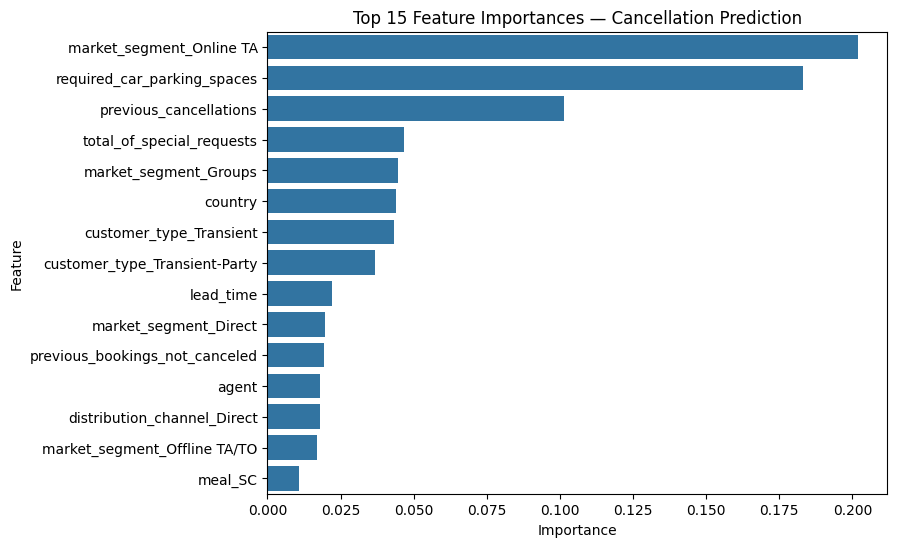

In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances — Cancellation Prediction")
plt.show()

* With `deposit_type` removed, feature importance is now considerably more distributed across the remaining features, with no single feature dominating in the way `deposit_type_Non_Refund` previously did
* `market_segment_Online TA` (0.202) and `required_car_parking_spaces` (0.183) are now the leading predictors, followed by `previous_cancellations` (0.102) - together these three account for roughly half of total importance, a much more balanced profile than the near-9x gap seen with `deposit_type_Non_Refund` included
* The remaining top-15 features show a gradual, expected decline in importance (0.047 down to 0.011), consistent with a model drawing on a broad mix of booking behaviour (`previous_cancellations`, `total_of_special_requests`), booking channel (`market_segment_*`, `distribution_channel_Direct`, `agent`), and customer type (`customer_type_Transient*`) rather than relying heavily on any single variable
* This more balanced importance distribution, combined with the negligible change in recall following the feature's removal, supports the model's predictive performance not being dependent on any one feature, and the final model is less susceptible to the risk of relying on a feature with uncertain derivation

In [23]:
feature_importance_df.tail(15)

,Feature,Importance
17,arrival_date_month_May,0.004107
43,reserved_room_type_D,0.004073
20,arrival_date_month_June,0.004016
5,children,0.003947
26,arrival_date_month_April,0.003889
1,arrival_date_day_of_month,0.003810
48,reserved_room_type_H,0.003753
33,market_segment_Corporate,0.003716
24,arrival_date_month_March,0.003574
42,reserved_room_type_G,0.002583


In [24]:
feature_importance_df.tail(15).sum()

Feature       arrival_date_month_Mayreserved_room_type_Darri...
Importance                                             0.048008
dtype: object

In [ ]:
from sklearn.model_selection import cross_validate

results = {}
pipelines = {
    "with_deposit": updated_classification_model_pipeline,
    "without_deposit": classification_model_pipeline_no_deposit
}

for name, pipeline in pipelines.items():

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='f1',
        return_train_score=False,
        n_jobs=-1
    )

    results[name] = {
        "Mean CV F1": cv_results["test_score"].mean(),
        "CV Std F1": cv_results["test_score"].std(),
        "Individual Scores": cv_results["test_score"]
    }


cv_comparison = pd.DataFrame(results).T
cv_comparison

* The F1 score comparison confirms that there is insignificant impact on the results to warrant keeping the deposit_type feature
* There is ambiguity in how the variable is derived leading to concerns that there could be data-leakage: 

>Value calculated based on the payments identified for the booking in the transaction (TR) table before the booking׳s arrival or cancellation date. <br>
>Non Refund – a deposit was made in the value of the total stay cost; [*Hotel booking demand datasets*](https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/)

* Although it was the most influential feature in the initial model (accounting for 87% of feature importance), its calculation relies on transaction information recorded before the booking’s arrival or cancellation date, raising uncertainty around whether this information would be available at the point of prediction. 
* In addition, the strong association between the Non Refund category and cancellations (Non Refund carries a 99% cancellation rate) suggests that the feature may act as a proxy for the target rather than capturing independent predictive behaviour. 
* Ablation testing showed that removing `deposit_type` resulted in only a marginal reduction in model performance (~1% decrease in F1 score and precision), while producing a more balanced feature importance distribution and a more robust, interpretable model. 
* Therefore, `deposit_type` will be removed from the final model to reduce leakage risk or model over-reliance without materially impacting predictive performance.

* Update the preprocessing pipelines to reflect the removal of `deposit_type`

In [ ]:
outlier_cols = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights"]
categorical_cols = ["hotel", "meal", "market_segment", "distribution_channel", "reserved_room_type", "assigned_room_type", "customer_type"]

def preprocessing():

    pipeline_base = Pipeline([
        ("DropFeatures", DropFeatures(features_to_drop=["company", "arrival_date_year", "deposit_type", "arrival_date_week_number"])),
        ("FunctionTransformer", FunctionTransformer(undefined_meal)),
        ("ArbitraryNumberImputer", ArbitraryNumberImputer(arbitrary_number=0, variables="agent")),
        ("CategoricalImputer", CategoricalImputer(imputation_method="frequent", variables="country")),
        ("Winsorizer", Winsorizer(capping_method="iqr", tail="right", fold=1.5, variables=outlier_cols)),
        ("RareLabelEncoder", RareLabelEncoder(tol=0.01, variables="country")),
        ("OrdinalEncoder", OrdinalEncoder(encoding_method="arbitrary", variables="country", ignore_format=True)),
        ("MonthEncoder", OneHotEncoder(variables="arrival_date_month")), 
        ("OneHotEncoder", OneHotEncoder(variables=categorical_cols, drop_last=True))
    ])

    return pipeline_base

preprocessing_pipeline = preprocessing()

In [ ]:
def prediction():

    pipeline_base = Pipeline([
        ("Preprocessing", preprocessing_pipeline),
        ("model", XGBClassifier(random_state=0, n_estimators=500, min_child_weight=10, gamma=0.1))
    ])

    return pipeline_base

prediction_pipeline = prediction()

In [ ]:
X = X_train.copy()
y = y_train.copy()

prediction_pipeline.fit(X, y)

In [ ]:
y_train_pred_final = prediction_pipeline.predict(X_train)
y_test_pred_final = prediction_pipeline.predict(X_test)

print("TRAIN SET\n")
print(classification_report(y_train, y_train_pred_final, target_names=["Not Cancelled", "Cancelled"]))
print("TEST SET\n")
print(classification_report(y_test, y_test_pred_final, target_names=["Not Cancelled", "Cancelled"]))

---

## Conclusions

**Overfitting**
* Initial evaluation of the v1 pipeline showed a substantial train/test recall gap (15.6 point difference) combined with near perfect train set scores (1.00 or 0.99 across all metrics). This suggested the model was overfitting to the training data despite meeting the 0.80 recall target on the test set. 
* Targeted hyperparameter tuning — reducing `max_depth` to its default, increasing `min_child_weight` to 10, and adding `gamma=0.1` — reduced this gap to 6.0 points (train 0.88, test 0.82) with only marginal cost to test recall, producing a model with a more realistic generalisation profile.

**Feature Importance**
* Feature importance analysis of the retuned model showed `deposit_type_Non_Refund` accounting for approximately 87% of total importance, far exceeding any other feature. 
* The deposit type "Non Refund" had a cancellation rate of 99% as discovered in the [cancellation eda](/jupyter_notebooks/02_cancellation_eda.ipynb) notebook and combined with the feature's high importance in the model, this raised a concern that this feature could be acting as a proxy for `is_canceled`rather than an independent predictor
* Investigation of the feature's derivation raised a data leakage concern: it is calculated from transaction records that may only be finalised at or near the point of cancellation, meaning it could encode information not genuinely available at prediction time. 
* An ablation study confirmed the feature was not essential to model performance — removing it produced a negligible drop in F1, precision, and recall (≤0.01 across all three) — while yielding a more balanced feature importance distribution across the remaining predictors. 
* `deposit_type` was therefore removed from the final pipeline (v2) to reduce leakage risk and produce a more interpretable, robust model without a meaningful performance cost.

**Business Requirement 2**
* The final v2 pipeline achieves a test recall of 0.82 for the Cancelled class, exceeding the 0.80 target defined in the ML Business Case. Combined with the reduced overfitting gap and removal of a feature carrying leakage risk, the model is considered fit for integration into the operational dashboard to answer Business Requirement 2.

**Limitations and Next Steps**
* The remaining ~6 point train/test gap suggests some overfitting persists; further regularisation (`reg_alpha`/`reg_lambda`) could be explored in a future iteration if time allows.
* `deposit_type`'s removal was justified via ablation on this dataset only; if the feature's true derivation timing can be confirmed with the data provider, its reinstatement could be reconsidered.

---

## Save Files

In [ ]:
import os
try:
  os.makedirs(name='outputs/ml_pipeline/cancel_predict/v2')
except Exception as e:
  print(e)


* Save updated preprocessing pipeline

In [ ]:
joblib.dump(value=preprocessing_pipeline, filename="outputs/ml_pipeline/cancel_predict/v2/classification_preprocessing_pipeline.pkl")

* Save the updated prediction pipeline

In [ ]:
joblib.dump(value=prediction_pipeline, filename="outputs/ml_pipeline/cancel_predict/v2/classification_model_pipeline.pkl")